<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_21_%D2%B0%D1%81%D1%8B%D0%BD%D1%8B%D1%81_%D0%B6%D2%AF%D0%B9%D0%B5%D0%BB%D0%B5%D1%80%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Өздік жұмыс: Жасырын кері байланыс (Implicit Feedback) негізінде ұсыныс жүйелерін құру

**Жұмыстың мақсаты:** Алған теориялық және практикалық білімді бекіту. Шынайы деректер базасымен жұмыс істей отырып, жасырын кері байланыс (implicit feedback) негізінде ALS (Alternating Least Squares) және SLIM (Sparse Linear Methods) алгоритмдерін өздігінен оқытып, толыққанды ұсыныс жүйесінің құбырын (pipeline) құрастыру.

## Деректерді таңдау (Datasets)

Төменде көрсетілген 5 датасеттің бірін (өз қызығушылығыңызға қарай) таңдап, жүктеп алыңыз. Содан соң төмендегі қадамдар бойынша код жазып, тапсырманы орындаңыз.

* **1. Электронды коммерция:** [Retailrocket Recommender System](https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset) (Қарау, себетке салу, сатып алу логтары)
* **2. Музыка индустриясы:**
* **3. Бөлшек сауда:** [Instacart Market Basket Analysis](https://www.google.com/search?q=https://www.kaggle.com/c/instacart-market-basket-analysis/data) (Азық-түлік себетін талдау)
* **4. Сән әлемі:** [H&M Personalized Fashion Recommendations](https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data) (Киімдерді сатып алу тарихы)
* **5. Аниме индустриясы:** [Anime Recommendations Database](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database) (Көрген фактілерін ғана қалдырып, тазалау қажет)

## 1-қадам. Деректерді жүктеу және талдау (EDA)

**Мақсаты:** Таңдалған датасетті оқу, құрылымымен танысу. Нақты рейтингтердің орнына қолданушының әрекеттерін (сатып алу, қарау, тыңдау саны) көрсететін бағандарды анықтап, қажетсіз деректерден тазарту.

In [1]:
!pip install implicit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 22.5 MB/s eta 0:00:00


In [2]:
# Кодты осында жазыңыз
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import (
    csr_matrix,
    csc_matrix,
    lil_matrix
)

from sklearn.linear_model import ElasticNet
from implicit.als import AlternatingLeastSquares

import implicit

print("implicit нұсқасы:", implicit.__version__)

implicit нұсқасы: 0.7.3


1-қадам. Деректерді жүктеу және талдау — EDA

1.1 Деректерді оқу

In [3]:
import os

ANIME_PATH = "/content/anime.csv"
RATING_PATH = "/content/rating.csv"

if not os.path.exists(ANIME_PATH):
    raise FileNotFoundError(
        f"{ANIME_PATH} файлы табылмады. "
        "anime.csv файлын ноутбук орналасқан папкаға салыңыз."
    )

if not os.path.exists(RATING_PATH):
    raise FileNotFoundError(
        f"{RATING_PATH} файлы табылмады. "
        "rating.csv файлын ноутбук орналасқан папкаға салыңыз."
    )

anime = pd.read_csv(ANIME_PATH)
ratings = pd.read_csv(RATING_PATH)

print("anime.csv өлшемі:", anime.shape)
print("rating.csv өлшемі:", ratings.shape)

anime.csv өлшемі: (12294, 7)
rating.csv өлшемі: (2112239, 3)


1.2 Алғашқы жолдарды қарау

In [4]:
display(anime.head())
display(ratings.head())

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


,user_id,anime_id,rating
0,1,20,-1.0
1,1,24,-1.0
2,1,79,-1.0
3,1,226,-1.0
4,1,241,-1.0


1.3 Деректер туралы жалпы ақпарат

In [5]:
print("ANIME DATAFRAME")
anime.info()

print("\nRATINGS DATAFRAME")
ratings.info()

ANIME DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB

RATINGS DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112239 entries, 0 to 2112238
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   user_id   int64  
 1   anime_id  int64  
 2   rating    float64
dtypes: float64(1), int64(2)
memory usage: 48.3 MB


In [6]:
print("Anime бос мәндері:")
display(anime.isnull().sum())

print("\nRatings бос мәндері:")
display(ratings.isnull().sum())

Anime бос мәндері:


,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0



Ratings бос мәндері:


,0
user_id,0
anime_id,0
rating,1


1.4 Қайталанатын жазбаларды тексеру

In [7]:
print("anime.csv қайталанатын жолдары:", anime.duplicated().sum())
print("rating.csv қайталанатын жолдары:", ratings.duplicated().sum())

print(
    "Қолданушы–аниме бойынша қайталанатын әрекеттер:",
    ratings.duplicated(subset=["user_id", "anime_id"]).sum()
)

anime.csv қайталанатын жолдары: 0
rating.csv қайталанатын жолдары: 0
Қолданушы–аниме бойынша қайталанатын әрекеттер: 0


1.5 Деректерді тазалау

Бұл датасетте rating = -1 пайдаланушының анимені көргенін, бірақ рейтинг қоймағанын білдіреді. Implicit feedback жағдайында бізге рейтингтің нақты мәнінен гөрі көру фактісі маңызды.

Сондықтан:

жарамсыз идентификаторлар жойылады;
қайталанатын user_id–anime_id жұптары біріктіріледі;
interaction мәні 1 болады;
өте аз әрекеті бар қолданушылар жойылады;
өте аз қаралған анимелер жойылады.

In [8]:
ratings_clean = ratings.copy()

# Қажетті бағандар ғана
ratings_clean = ratings_clean[
    ["user_id", "anime_id", "rating"]
].copy()

# Бос мәндерді жою
ratings_clean = ratings_clean.dropna(
    subset=["user_id", "anime_id"]
)

# ID мәндерін бүтін санға айналдыру
ratings_clean["user_id"] = ratings_clean["user_id"].astype(int)
ratings_clean["anime_id"] = ratings_clean["anime_id"].astype(int)

# Жарамсыз ID мәндерін жою
ratings_clean = ratings_clean[
    (ratings_clean["user_id"] > 0) &
    (ratings_clean["anime_id"] > 0)
].copy()

# Анимені көру фактісі implicit interaction ретінде белгіленеді
ratings_clean["interaction"] = 1.0

# Бір қолданушы бір анимеге бірнеше рет кездессе, бір әрекет қана қалдырамыз
ratings_clean = (
    ratings_clean
    .groupby(["user_id", "anime_id"], as_index=False)
    .agg(
        interaction=("interaction", "max"),
        original_rating=("rating", "max")
    )
)

print("Тазалаудан кейінгі өлшем:", ratings_clean.shape)
display(ratings_clean.head())

Тазалаудан кейінгі өлшем: (2112239, 4)


,user_id,anime_id,interaction,original_rating
0,1,20,1.0,-1.0
1,1,24,1.0,-1.0
2,1,79,1.0,-1.0
3,1,226,1.0,-1.0
4,1,241,1.0,-1.0


1.6 Белсенділігі төмен қолданушылар мен сирек анимелерді сүзу

Сирек объектілер recommendation моделін оқыту кезінде артық шу туғызуы мүмкін.

In [9]:
MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5
MAX_FILTER_ITERATIONS = 10

filtered = ratings_clean.copy()

for iteration in range(MAX_FILTER_ITERATIONS):
    old_size = len(filtered)

    user_counts = filtered.groupby("user_id").size()
    valid_users = user_counts[
        user_counts >= MIN_USER_INTERACTIONS
    ].index

    filtered = filtered[
        filtered["user_id"].isin(valid_users)
    ]

    item_counts = filtered.groupby("anime_id").size()
    valid_items = item_counts[
        item_counts >= MIN_ITEM_INTERACTIONS
    ].index

    filtered = filtered[
        filtered["anime_id"].isin(valid_items)
    ]

    filtered = filtered.reset_index(drop=True)

    print(
        f"{iteration + 1}-итерация: "
        f"{len(filtered):,} әрекет қалды"
    )

    if len(filtered) == old_size:
        break

ratings_filtered = filtered.copy()

1-итерация: 2,103,666 әрекет қалды
2-итерация: 2,103,666 әрекет қалды


1.7 Тазаланған деректер статистикасы

In [10]:
n_users = ratings_filtered["user_id"].nunique()
n_items = ratings_filtered["anime_id"].nunique()
n_interactions = len(ratings_filtered)

sparsity = 1 - (
    n_interactions / (n_users * n_items)
)

print(f"Қолданушылар саны: {n_users:,}")
print(f"Анимелер саны: {n_items:,}")
print(f"Әрекеттер саны: {n_interactions:,}")
print(f"Матрицаның sparsity деңгейі: {sparsity:.6%}")

Қолданушылар саны: 18,622
Анимелер саны: 6,982
Әрекеттер саны: 2,103,666
Матрицаның sparsity деңгейі: 98.382029%


1.8 Ең танымал анимелер

In [11]:
anime_popularity = (
    ratings_filtered
    .groupby("anime_id")
    .agg(
        interaction_count=("user_id", "count"),
        unique_users=("user_id", "nunique")
    )
    .reset_index()
)

popular_anime = (
    anime_popularity
    .merge(
        anime[["anime_id", "name", "genre", "type"]],
        on="anime_id",
        how="left"
    )
    .sort_values(
        "interaction_count",
        ascending=False
    )
)

display(popular_anime.head(15))

,anime_id,interaction_count,unique_users,name,genre,type
1366,1535,10759,10759,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV
4901,11757,9348,9348,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV
5452,16498,9064,9064,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV
3792,6547,7674,7674,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV
1400,1575,7610,7610,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV
201,226,7465,7465,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV
10,20,7141,7141,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV
3403,5114,6869,6869,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV
3134,4224,6812,6812,Toradora!,"Comedy, Romance, School, Slice of Life",TV
99,121,6767,6767,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV


1.9 Танымал анимелердің диаграммасы

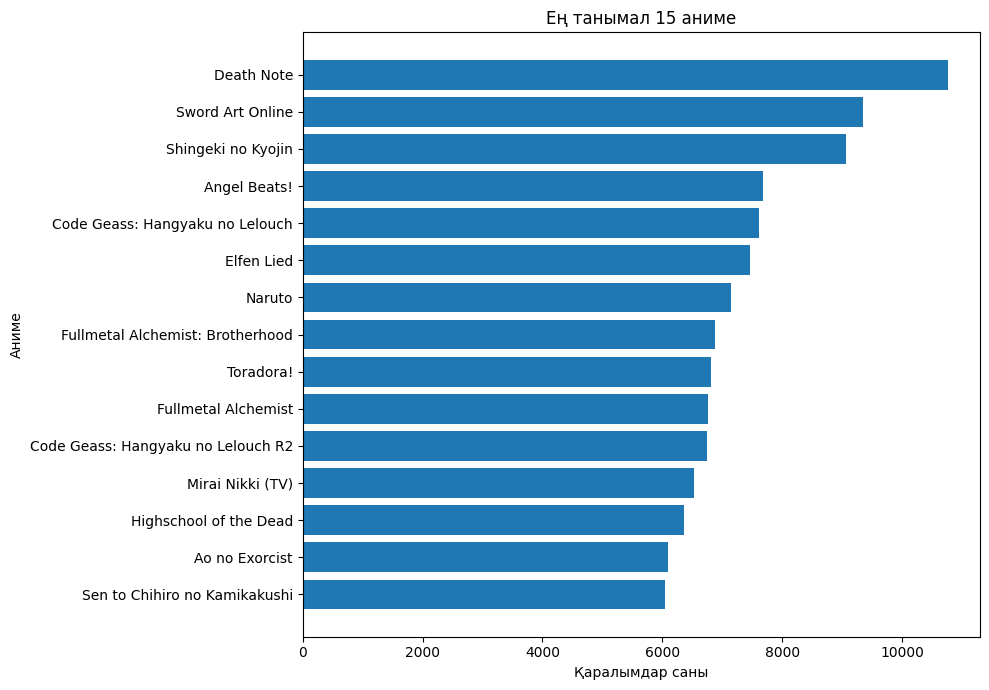

In [12]:
top_popular = popular_anime.head(15).sort_values(
    "interaction_count"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_popular["name"],
    top_popular["interaction_count"]
)
plt.xlabel("Қаралымдар саны")
plt.ylabel("Аниме")
plt.title("Ең танымал 15 аниме")
plt.tight_layout()
plt.show()

1-қадам бойынша қорытынды

In [13]:
print(
    "EDA қорытындысы:\n"
    f"- {n_users:,} белсенді қолданушы қалды;\n"
    f"- {n_items:,} аниме қалды;\n"
    f"- {n_interactions:,} implicit interaction пайдаланылды;\n"
    f"- матрица sparsity деңгейі: {sparsity:.6%}."
)

EDA қорытындысы:
- 18,622 белсенді қолданушы қалды;
- 6,982 аниме қалды;
- 2,103,666 implicit interaction пайдаланылды;
- матрица sparsity деңгейі: 98.382029%.


2-қадам. User–Item сирек матрицасын құру

2.1 Қолданушы және аниме индекстерін құру

ALS және SLIM модельдері нөлден басталатын реттік индекстермен жұмыс істейді.

In [14]:
unique_users = np.sort(
    ratings_filtered["user_id"].unique()
)

unique_items = np.sort(
    ratings_filtered["anime_id"].unique()
)

user_id_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(unique_users)
}

idx_to_user_id = {
    idx: user_id
    for user_id, idx in user_id_to_idx.items()
}

anime_id_to_idx = {
    anime_id: idx
    for idx, anime_id in enumerate(unique_items)
}

idx_to_anime_id = {
    idx: anime_id
    for anime_id, idx in anime_id_to_idx.items()
}

In [15]:
ratings_filtered["user_idx"] = (
    ratings_filtered["user_id"]
    .map(user_id_to_idx)
)

ratings_filtered["item_idx"] = (
    ratings_filtered["anime_id"]
    .map(anime_id_to_idx)
)

display(ratings_filtered.head())

,user_id,anime_id,interaction,original_rating,user_idx,item_idx
0,1,20,1.0,-1.0,0,10
1,1,24,1.0,-1.0,0,13
2,1,79,1.0,-1.0,0,57
3,1,226,1.0,-1.0,0,201
4,1,241,1.0,-1.0,0,215


2.2 Binary User–Item матрицасы



In [16]:
rows = ratings_filtered["user_idx"].to_numpy()
cols = ratings_filtered["item_idx"].to_numpy()
values = ratings_filtered["interaction"].to_numpy(
    dtype=np.float32
)

user_item_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(unique_users), len(unique_items)),
    dtype=np.float32
)

print("User–Item matrix shape:", user_item_matrix.shape)
print("Нөл емес элементтер саны:", user_item_matrix.nnz)

User–Item matrix shape: (18622, 6982)
Нөл емес элементтер саны: 2103666


2.3 Confidence матрицасын есептеу


In [17]:
ALPHA_CONFIDENCE = 20.0

confidence_matrix = user_item_matrix.copy().astype(
    np.float32
)

confidence_matrix.data = (
    1.0 +
    ALPHA_CONFIDENCE * confidence_matrix.data
)

print("Binary interaction мәндері:")
print(np.unique(user_item_matrix.data))

print("\nConfidence мәндері:")
print(np.unique(confidence_matrix.data))

Binary interaction мәндері:
[1.]

Confidence мәндері:
[21.]


2.4 Матрица тығыздығы

In [18]:
matrix_density = (
    user_item_matrix.nnz /
    (
        user_item_matrix.shape[0] *
        user_item_matrix.shape[1]
    )
)

print(f"Матрица тығыздығы: {matrix_density:.8%}")
print(f"Матрица сиректігі: {1 - matrix_density:.8%}")

Матрица тығыздығы: 1.61797058%
Матрица сиректігі: 98.38202942%


3-қадам. ALS алгоритмін оқыту

3.1 ALS моделін құру

In [19]:
ALS_FACTORS = 64
ALS_REGULARIZATION = 0.05
ALS_ITERATIONS = 20
RANDOM_STATE = 42

als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REGULARIZATION,
    iterations=ALS_ITERATIONS,
    random_state=RANDOM_STATE
)

print(als_model)

3.2 Модельді оқыту

In [20]:
als_model.fit(
    confidence_matrix,
    show_progress=True
)

  0%|          | 0/20 [00:00<?, ?it/s]

3.3 Модель өлшемдерін тексеру

In [21]:
print(
    "User factors shape:",
    als_model.user_factors.shape
)

print(
    "Item factors shape:",
    als_model.item_factors.shape
)

User factors shape: (18622, 64)
Item factors shape: (6982, 64)


3.4 Аниме ақпаратын қайтаратын көмекші функция

In [22]:
anime_info = (
    anime
    .drop_duplicates(subset=["anime_id"])
    .set_index("anime_id")
)

In [23]:
def get_anime_name(anime_id):
    """
    anime_id бойынша аниме атауын қайтарады.
    """
    if anime_id in anime_info.index:
        return anime_info.loc[anime_id, "name"]

    return f"Unknown anime #{anime_id}"

In [24]:
def get_anime_genre(anime_id):
    """
    anime_id бойынша жанрды қайтарады.
    """
    if anime_id in anime_info.index:
        genre = anime_info.loc[anime_id, "genre"]

        if pd.isna(genre):
            return "Жанры белгісіз"

        return genre

    return "Жанры белгісіз"

3.5 ALS Top-N ұсыныс функциясы

In [25]:
def recommend_als(user_id, n=5):
    """
    Берілген қолданушыға ALS арқылы Top-N ұсыныс береді.
    Бұрын көрген анимелер автоматты түрде алынып тасталады.
    """
    if user_id not in user_id_to_idx:
        raise ValueError(
            f"{user_id} қолданушысы модельде жоқ."
        )

    user_idx = user_id_to_idx[user_id]

    recommended_indices, scores = als_model.recommend(
        userid=user_idx,
        user_items=user_item_matrix[user_idx],
        N=n,
        filter_already_liked_items=True
    )

    result = []

    for rank, (item_idx, score) in enumerate(
        zip(recommended_indices, scores),
        start=1
    ):
        anime_id = idx_to_anime_id[int(item_idx)]

        result.append({
            "rank": rank,
            "anime_id": anime_id,
            "name": get_anime_name(anime_id),
            "genre": get_anime_genre(anime_id),
            "ALS_score": float(score)
        })

    return pd.DataFrame(result)

3.6 Тест қолданушысына ұсыныс

In [26]:
test_user_id = unique_users[0]

print("Қолданушы:", test_user_id)
display(recommend_als(test_user_id, n=5))

Қолданушы: 1


,rank,anime_id,name,genre,ALS_score
0,1,10213,Maji de Watashi ni Koi Shinasai!,"Comedy, Ecchi, Harem, Martial Arts, Romance, S...",1.215616
1,2,20021,Sword Art Online: Extra Edition,"Action, Adventure, Fantasy, Game, Romance",1.082856
2,3,18001,Freezing Vibration,"Action, Drama, Ecchi, Harem, Martial Arts, Mil...",1.080527
3,4,6347,Baka to Test to Shoukanjuu,"Comedy, Romance, School, Super Power",1.062602
4,5,17641,Date A Live: Date to Date,"Comedy, Harem, Romance, School, Sci-Fi",1.060278


4-қадам. SLIM алгоритмін оқыту


ElasticNet L1 және L2 регуляризацияларын біріктіреді. l1_ratio L1 және L2 айыптарының арасындағы қатынасты, ал alpha жалпы регуляризация күшін басқарады.

4.1 Ең танымал 500 аниме таңдау

In [27]:
SLIM_TOP_ITEMS = 500

item_popularity = np.asarray(
    user_item_matrix.sum(axis=0)
).ravel()

popular_item_indices = np.argsort(
    -item_popularity
)[:SLIM_TOP_ITEMS]

print(
    "SLIM үшін таңдалған объектілер саны:",
    len(popular_item_indices)
)

SLIM үшін таңдалған объектілер саны: 500


4.2 SLIM матрицасын дайындау

In [28]:
slim_user_item = user_item_matrix[
    :,
    popular_item_indices
].copy().astype(np.float32)

print(
    "SLIM User–Item matrix shape:",
    slim_user_item.shape
)

print(
    "SLIM матрицасындағы interactions:",
    slim_user_item.nnz
)

SLIM User–Item matrix shape: (18622, 500)
SLIM матрицасындағы interactions: 1128770


4.3 SLIM гиперпараметрлері

In [33]:
SLIM_ALPHA = 0.001
SLIM_L1_RATIO = 0.1
SLIM_MAX_ITER = 100
SLIM_TOL = 1e-4

4.4 W салмақтар матрицасын есептеу

In [30]:
def train_slim_elasticnet(
    interaction_matrix,
    alpha=0.001,
    l1_ratio=0.1,
    max_iter=100,
    tol=1e-4
):
    """
    SLIM моделінің W Item–Item матрицасын ElasticNet арқылы есептейді.

    interaction_matrix:
        users × items sparse матрицасы.

    Нәтиже:
        items × items sparse W матрицасы.
    """
    X = interaction_matrix.tocsc(
        copy=True
    ).astype(np.float32)

    n_users, n_items = X.shape

    W = lil_matrix(
        (n_items, n_items),
        dtype=np.float32
    )

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        positive=True,
        fit_intercept=False,
        copy_X=False,
        precompute=False,
        max_iter=max_iter,
        tol=tol,
        selection="random",
        random_state=RANDOM_STATE
    )

    for target_item in range(n_items):
        # target_item бағанының бастапқы орнын анықтаймыз
        start = X.indptr[target_item]
        end = X.indptr[target_item + 1]

        # Мақсатты y векторы
        y = X[:, target_item].toarray().ravel()

        if np.count_nonzero(y) == 0:
            continue

        # Объект өз-өзін болжауға қатыспауы керек
        saved_values = X.data[start:end].copy()
        X.data[start:end] = 0.0

        # ElasticNet моделін оқыту
        model.fit(X, y)

        coefficients = model.coef_.copy()
        coefficients[target_item] = 0.0

        # Нөлден үлкен коэффициенттер ғана сақталады
        nonzero_indices = np.flatnonzero(
            coefficients > 0
        )

        if len(nonzero_indices) > 0:
            W[nonzero_indices, target_item] = (
                coefficients[nonzero_indices]
            )

        # Бастапқы бағанды қалпына келтіру
        X.data[start:end] = saved_values

        if (
            (target_item + 1) % 50 == 0 or
            target_item == n_items - 1
        ):
            print(
                f"SLIM: {target_item + 1}/{n_items} "
                "объект оқытылды"
            )

    return W.tocsr()

In [32]:
MAX_SLIM_USERS = 30000

if slim_user_item.shape[0] > MAX_SLIM_USERS:
    rng = np.random.default_rng(RANDOM_STATE)

    active_users = np.where(
        np.asarray(
            slim_user_item.sum(axis=1)
        ).ravel() > 0
    )[0]

    selected_slim_users = rng.choice(
        active_users,
        size=min(MAX_SLIM_USERS, len(active_users)),
        replace=False
    )

    slim_train_matrix = slim_user_item[
        selected_slim_users
    ].copy()
else:
    selected_slim_users = np.arange(
        slim_user_item.shape[0]
    )

    slim_train_matrix = slim_user_item.copy()

print(
    "SLIM оқыту матрицасының өлшемі:",
    slim_train_matrix.shape
)

SLIM оқыту матрицасының өлшемі: (18622, 500)


In [34]:
slim_W = train_slim_elasticnet(
    interaction_matrix=slim_train_matrix,
    alpha=SLIM_ALPHA,
    l1_ratio=SLIM_L1_RATIO,
    max_iter=SLIM_MAX_ITER,
    tol=SLIM_TOL
)

SLIM: 50/500 объект оқытылды
SLIM: 100/500 объект оқытылды
SLIM: 150/500 объект оқытылды
SLIM: 200/500 объект оқытылды
SLIM: 250/500 объект оқытылды
SLIM: 300/500 объект оқытылды
SLIM: 350/500 объект оқытылды
SLIM: 400/500 объект оқытылды
SLIM: 450/500 объект оқытылды
SLIM: 500/500 объект оқытылды


4.5 W матрицасын тексеру

In [35]:
print("SLIM W shape:", slim_W.shape)
print("W нөл емес элементтері:", slim_W.nnz)

w_density = (
    slim_W.nnz /
    (slim_W.shape[0] * slim_W.shape[1])
)

print(f"W матрицасының тығыздығы: {w_density:.6%}")

SLIM W shape: (500, 500)
W нөл емес элементтері: 21971
W матрицасының тығыздығы: 8.788400%


4.6 Диагональ мәндерін тексеру

In [36]:
diagonal_values = slim_W.diagonal()

print(
    "W диагоналіндегі ең үлкен мән:",
    diagonal_values.max()
)

assert np.allclose(
    diagonal_values,
    0
), "W матрицасының диагоналі нөл болуы керек."

W диагоналіндегі ең үлкен мән: 0.0


4.7 SLIM Top-N ұсыныс функциясы

In [37]:
def recommend_slim(user_id, n=5):
    """
    Берілген қолданушыға SLIM арқылы Top-N ұсыныс береді.
    """
    if user_id not in user_id_to_idx:
        raise ValueError(
            f"{user_id} қолданушысы модельде жоқ."
        )

    user_idx = user_id_to_idx[user_id]

    # Қолданушының ең танымал 500 аниме ішіндегі тарихы
    user_profile = slim_user_item[
        user_idx
    ]

    # score = user_profile × W
    scores = (
        user_profile @ slim_W
    ).toarray().ravel()

    # Бұрын көрген объектілерді ұсынбау
    seen_local_indices = user_profile.indices
    scores[seen_local_indices] = -np.inf

    # Шекті жағдайда ұсынылатын объект жетіспесе
    available_count = np.sum(
        np.isfinite(scores)
    )

    top_n = min(n, available_count)

    if top_n == 0:
        return pd.DataFrame(
            columns=[
                "rank",
                "anime_id",
                "name",
                "genre",
                "SLIM_score"
            ]
        )

    candidate_indices = np.argpartition(
        scores,
        -top_n
    )[-top_n:]

    candidate_indices = candidate_indices[
        np.argsort(
            scores[candidate_indices]
        )[::-1]
    ]

    result = []

    for rank, local_item_idx in enumerate(
        candidate_indices,
        start=1
    ):
        global_item_idx = popular_item_indices[
            local_item_idx
        ]

        anime_id = idx_to_anime_id[
            int(global_item_idx)
        ]

        result.append({
            "rank": rank,
            "anime_id": anime_id,
            "name": get_anime_name(anime_id),
            "genre": get_anime_genre(anime_id),
            "SLIM_score": float(
                scores[local_item_idx]
            )
        })

    return pd.DataFrame(result)

SLIM ұсынысын тексеру:

In [38]:
display(
    recommend_slim(
        test_user_id,
        n=5
    )
)

,rank,anime_id,name,genre,SLIM_score
0,1,13161,Hagure Yuusha no Aesthetica,"Action, Ecchi, Fantasy, Super Power",0.669487
1,2,6201,Princess Lover!,"Comedy, Ecchi, Harem, School",0.661794
2,3,24703,High School DxD BorN,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",0.616923
3,4,27787,Nisekoi:,"Comedy, Harem, Romance, School, Shounen",0.594282
4,5,23277,Saenai Heroine no Sodatekata,"Comedy, Ecchi, Harem, Romance, School",0.577137


5-қадам. Нәтижені бағалау және салыстыру

5.1 Қолданушының көрген анимелерін көрсету

In [39]:
def get_user_history(user_id, n=10):
    """
    Қолданушы бұрын көрген анимелерді көрсетеді.
    """
    if user_id not in user_id_to_idx:
        raise ValueError(
            f"{user_id} қолданушысы модельде жоқ."
        )

    user_rows = ratings_filtered[
        ratings_filtered["user_id"] == user_id
    ].copy()

    history = user_rows.merge(
        anime[
            [
                "anime_id",
                "name",
                "genre",
                "type"
            ]
        ],
        on="anime_id",
        how="left"
    )

    history = history[
        [
            "anime_id",
            "name",
            "genre",
            "type",
            "original_rating"
        ]
    ]

    history = history.sort_values(
        "original_rating",
        ascending=False
    )

    return history.head(n)

5.2 Екі белсенді қолданушыны таңдау

SLIM тек ең танымал 500 анимемен жұмыс істейтіндіктен, осы жиында жеткілікті тарихы бар қолданушыларды таңдаймыз.

In [40]:
slim_user_activity = np.asarray(
    slim_user_item.sum(axis=1)
).ravel()

eligible_user_indices = np.where(
    (slim_user_activity >= 5) &
    (slim_user_activity < SLIM_TOP_ITEMS - 5)
)[0]

if len(eligible_user_indices) < 2:
    raise ValueError(
        "SLIM жиынында жеткілікті белсенді "
        "екі қолданушы табылмады."
    )

# Белсенділігі жоғары екі қолданушы
sorted_eligible = eligible_user_indices[
    np.argsort(
        -slim_user_activity[
            eligible_user_indices
        ]
    )
]

selected_user_indices = sorted_eligible[:2]

selected_user_ids = [
    idx_to_user_id[int(idx)]
    for idx in selected_user_indices
]

print(
    "Таңдалған қолданушылар:",
    selected_user_ids
)

Таңдалған қолданушылар: [np.int64(8115), np.int64(8149)]


5.3 ALS және SLIM нәтижелерін экранға шығару

In [41]:
for user_id in selected_user_ids:
    print("=" * 100)
    print(f"ҚОЛДАНУШЫ ID: {user_id}")
    print("=" * 100)

    print("\nҚолданушы бұрын көрген анимелер:")
    display(
        get_user_history(
            user_id,
            n=10
        )
    )

    print("\nALS ұсынған Top-5 аниме:")
    als_recommendations = recommend_als(
        user_id,
        n=5
    )
    display(als_recommendations)

    print("\nSLIM ұсынған Top-5 аниме:")
    slim_recommendations = recommend_slim(
        user_id,
        n=5
    )
    display(slim_recommendations)

ҚОЛДАНУШЫ ID: 8115

Қолданушы бұрын көрген анимелер:


,anime_id,name,genre,type,original_rating
7,19,Monster,"Drama, Horror, Mystery, Police, Psychological,...",TV,10.0
1250,28735,Shouwa Genroku Rakugo Shinjuu,"Drama, Historical, Josei",TV,10.0
479,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,10.0
1202,25013,Akatsuki no Yona,"Action, Adventure, Comedy, Fantasy, Romance, S...",TV,10.0
78,199,Sen to Chihiro no Kamikakushi,"Adventure, Drama, Supernatural",Movie,10.0
1143,22135,Ping Pong The Animation,"Psychological, Seinen, Sports",TV,10.0
260,1535,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,10.0
127,392,Yuu☆Yuu☆Hakusho,"Action, Comedy, Demons, Fantasy, Martial Arts,...",TV,10.0
421,4181,Clannad: After Story,"Drama, Fantasy, Romance, Slice of Life, Supern...",TV,10.0
812,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,10.0



ALS ұсынған Top-5 аниме:


,rank,anime_id,name,genre,ALS_score
0,1,2508,Genshiken 2,"Comedy, Parody, Slice of Life",1.164969
1,2,1813,Genshiken OVA,"Comedy, Parody, Slice of Life",1.127420
2,3,6046,Tales of Vesperia: The First Strike,"Action, Adventure, Fantasy, Magic, Military",1.115956
3,4,469,Karin,"Comedy, Romance, School, Shounen, Vampire",1.104877
4,5,26351,Nagato Yuki-chan no Shoushitsu,"Comedy, Romance, School, Seinen, Slice of Life",1.098933



SLIM ұсынған Top-5 аниме:


...

,anime_id,name,genre,type,original_rating
1067,10087,Fate/Zero,"Action, Fantasy, Supernatural",TV,10.0
1200,12189,Hyouka,"Mystery, School, Slice of Life",TV,10.0
989,9074,Arakawa Under the Bridge x Bridge,"Comedy, Romance, Seinen",TV,10.0
1348,16498,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,10.0
1334,16067,Nagi no Asukara,"Drama, Fantasy, Romance",TV,10.0
581,2593,Kara no Kyoukai 1: Fukan Fuukei,"Action, Mystery, Supernatural, Thriller",Movie,10.0
32,71,Full Metal Panic!,"Action, Comedy, Mecha, Military, Sci-Fi",TV,10.0
810,6114,Rainbow: Nisha Rokubou no Shichinin,"Drama, Historical, Seinen, Thriller",TV,10.0
790,5702,Sora wo Miageru Shoujo no Hitomi ni Utsuru Sekai,"Action, Fantasy, Magic, Romance, Super Power",TV,10.0
763,5310,Macross F Movie 1: Itsuwari no Utahime,"Action, Mecha, Military, Music, Romance, Sci-F...",Movie,10.0



ALS ұсынған Top-5 аниме:


,rank,anime_id,name,genre,ALS_score
0,1,481,Yu☆Gi☆Oh! Duel Monsters,"Adventure, Game, Shounen",1.241544
1,2,4155,One Piece Film: Strong World,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",1.187545
2,3,1894,Yu☆Gi☆Oh!: Hikari no Pyramid,"Adventure, Comedy, Fantasy, Game",1.180509
3,4,4262,Koihime†Musou,"Action, Adventure, Fantasy, Historical, Martia...",1.177688
4,5,391,Tales of Phantasia The Animation,"Adventure, Fantasy, Shounen",1.173338



SLIM ұсынған Top-5 аниме:


,rank,anime_id,name,genre,SLIM_score
0,1,237,Eureka Seven,"Adventure, Drama, Mecha, Romance, Sci-Fi",1.150017
1,2,23283,Zankyou no Terror,"Psychological, Thriller",1.056650
2,3,14227,Tonari no Kaibutsu-kun,"Comedy, Romance, School, Shoujo, Slice of Life",1.032887
3,4,6324,Omamori Himari,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",0.982075
4,5,1726,Devil May Cry,"Action, Demons, Fantasy",0.967705


ALS және SLIM ұсыныстарының ұқсастығын есептеу

Екі модельдің Top-5 ұсыныстары қаншалықты сәйкес келетінін Jaccard коэффициентімен бағалауға болады

In [42]:
def recommendation_overlap(user_id, n=5):
    als_result = recommend_als(
        user_id,
        n=n
    )

    slim_result = recommend_slim(
        user_id,
        n=n
    )

    als_items = set(
        als_result["anime_id"].tolist()
    )

    slim_items = set(
        slim_result["anime_id"].tolist()
    )

    intersection = als_items.intersection(
        slim_items
    )

    union = als_items.union(
        slim_items
    )

    jaccard = (
        len(intersection) / len(union)
        if len(union) > 0
        else 0.0
    )

    return {
        "user_id": user_id,
        "ALS_items": len(als_items),
        "SLIM_items": len(slim_items),
        "common_items": len(intersection),
        "jaccard_similarity": jaccard,
        "common_anime_ids": list(intersection)
    }

In [43]:
overlap_results = []

for user_id in selected_user_ids:
    overlap_results.append(
        recommendation_overlap(
            user_id,
            n=5
        )
    )

overlap_df = pd.DataFrame(
    overlap_results
)

display(overlap_df)

,user_id,ALS_items,SLIM_items,common_items,jaccard_similarity,common_anime_ids
0,8115,5,5,0,0.0,[]
1,8149,5,5,0,0.0,[]


Жанрлар бойынша логикалық бағалау

Қолданушының тарихындағы және ұсыныстардағы жанрларды салыстырамыз.

In [44]:
from collections import Counter


def split_genres(genre_series):
    genres = []

    for value in genre_series.dropna():
        parts = str(value).split(",")

        for genre in parts:
            cleaned_genre = genre.strip()

            if cleaned_genre:
                genres.append(cleaned_genre)

    return genres

In [45]:
def genre_overlap_analysis(user_id, n=5):
    history = get_user_history(
        user_id,
        n=20
    )

    als_result = recommend_als(
        user_id,
        n=n
    )

    slim_result = recommend_slim(
        user_id,
        n=n
    )

    history_genres = set(
        split_genres(
            history["genre"]
        )
    )

    als_genres = set(
        split_genres(
            als_result["genre"]
        )
    )

    slim_genres = set(
        split_genres(
            slim_result["genre"]
        )
    )

    als_common = history_genres.intersection(
        als_genres
    )

    slim_common = history_genres.intersection(
        slim_genres
    )

    return {
        "user_id": user_id,
        "history_top_genres": Counter(
            split_genres(
                history["genre"]
            )
        ).most_common(5),
        "ALS_common_genres": sorted(als_common),
        "SLIM_common_genres": sorted(slim_common),
        "ALS_genre_overlap_count": len(als_common),
        "SLIM_genre_overlap_count": len(slim_common)
    }

In [46]:
genre_analysis_results = []

for user_id in selected_user_ids:
    genre_analysis_results.append(
        genre_overlap_analysis(
            user_id,
            n=5
        )
    )

genre_analysis_df = pd.DataFrame(
    genre_analysis_results
)

display(genre_analysis_df)

,user_id,history_top_genres,ALS_common_genres,SLIM_common_genres,ALS_genre_overlap_count,SLIM_genre_overlap_count
0,8115,"[(Drama, 10), (Action, 8), (Romance, 6), (Come...","[Action, Adventure, Comedy, Fantasy, Magic, Mi...","[Action, Adventure, Comedy, Drama, Historical,...",11,14
1,8149,"[(Action, 12), (Drama, 9), (Fantasy, 8), (Roma...","[Action, Adventure, Comedy, Drama, Fantasy, Ga...","[Action, Adventure, Comedy, Drama, Fantasy, Me...",9,13


Нәтижелерді бір кестеде салыстыру

In [47]:
comparison_rows = []

for user_id in selected_user_ids:
    als_result = recommend_als(
        user_id,
        n=5
    )

    slim_result = recommend_slim(
        user_id,
        n=5
    )

    for rank in range(1, 6):
        als_row = als_result[
            als_result["rank"] == rank
        ]

        slim_row = slim_result[
            slim_result["rank"] == rank
        ]

        comparison_rows.append({
            "user_id": user_id,
            "rank": rank,
            "ALS_recommendation": (
                als_row.iloc[0]["name"]
                if len(als_row) > 0
                else None
            ),
            "ALS_score": (
                als_row.iloc[0]["ALS_score"]
                if len(als_row) > 0
                else None
            ),
            "SLIM_recommendation": (
                slim_row.iloc[0]["name"]
                if len(slim_row) > 0
                else None
            ),
            "SLIM_score": (
                slim_row.iloc[0]["SLIM_score"]
                if len(slim_row) > 0
                else None
            )
        })

comparison_df = pd.DataFrame(
    comparison_rows
)

display(comparison_df)

,user_id,rank,ALS_recommendation,ALS_score,SLIM_recommendation,SLIM_score
0,8115,1,Genshiken 2,1.164969,Rurouni Kenshin: Meiji Kenkaku Romantan,1.060596
1,8115,2,Genshiken OVA,1.127420,11eyes,1.026294
2,8115,3,Tales of Vesperia: The First Strike,1.115956,Ansatsu Kyoushitsu (TV),1.009147
3,8115,4,Karin,1.104877,Elfen Lied Special,0.967215
4,8115,5,Nagato Yuki-chan no Shoushitsu,1.098933,Azumanga Daioh,0.902629
5,8149,1,Yu☆Gi☆Oh! Duel Monsters,1.241544,Eureka Seven,1.150017
6,8149,2,One Piece Film: Strong World,1.187545,Zankyou no Terror,1.056650
7,8149,3,Yu☆Gi☆Oh!: Hikari no Pyramid,1.180509,Tonari no Kaibutsu-kun,1.032887
8,8149,4,Koihime†Musou,1.177688,Omamori Himari,0.982075
9,8149,5,Tales of Phantasia The Animation,1.173338,Devil May Cry,0.967705


Нәтижелерді CSV файлдарына сақтау

In [48]:
comparison_df.to_csv(
    "als_slim_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

overlap_df.to_csv(
    "recommendation_overlap.csv",
    index=False,
    encoding="utf-8-sig"
)

genre_analysis_df.to_csv(
    "genre_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Нәтижелер CSV файлдарына сақталды.")

Нәтижелер CSV файлдарына сақталды.


Қорытынды мәтін

Бұл жұмыста Anime Recommendations Database деректері негізінде жасырын кері байланысқа арналған екі ұсыныс алгоритмі құрылды. Қолданушының анимені көру фактісі binary implicit interaction ретінде қабылданды. Бастапқы деректер тазартылып, белсенділігі төмен қолданушылар мен сирек қаралған анимелер алынып тасталды. Нәтижесінде User–Item форматындағы сирек матрица құрылды.

ALS моделінде қолданушы мен анимелер төмен өлшемді latent факторлар арқылы сипатталды. ALS бүкіл User–Item матрицасындағы жасырын байланыстарды анықтайды. Сондықтан ол пайдаланушы көрмеген, бірақ талғамына сәйкес келуі ықтимал жаңа анимелерді ұсына алады. Модель үшін 64 latent factor, 0.05 regularization және 20 iteration қолданылды.

SLIM моделінде әрбір аниме басқа анимелердің sparse сызықтық комбинациясы ретінде қарастырылды. ElasticNet регуляризациясы салмақтар матрицасының сирек болуын қамтамасыз етті. Есептеу ресурстарын үнемдеу мақсатында ең танымал 500 аниме пайдаланылды. SLIM көбінесе пайдаланушы бұрын көрген анимелерге тікелей ұқсас және бірге қаралатын объектілерді ұсынды.

ALS пен SLIM нәтижелерін салыстырғанда олардың кейбір ұсыныстары сәйкес келуі мүмкін, бірақ толық сәйкес болмауы қалыпты жағдай. ALS latent факторларға негізделгендіктен, пайдаланушы қызығушылығының жасырын құрылымын анықтайды. SLIM Item–Item байланыстарына негізделгендіктен, түсіндіруге жеңіл ұсыныстар береді. Мысалы, SLIM ұсынған аниме пайдаланушы бұрын көрген белгілі бір анимемен жиі бірге қаралған деп түсіндіруге болады.

Осылайша, үлкен және өте сирек interaction матрицалары үшін ALS тиімдірек және масштабталуы жақсы модель болып табылады. SLIM ұсыныстары түсініктірек, бірақ әрбір объект үшін жеке ElasticNet моделін оқыту қажет болғандықтан, есептеу уақыты көбірек болады. Практикалық recommendation system-де ALS негізгі кандидаттарды қалыптастыру үшін, ал SLIM ұқсас объектілерді анықтау немесе ұсыныстарды қайта ранжирлеу үшін қолданылуы мүмкін.